# High Quality Equity Index : Construction and Performance Evaluation

## Data Collection
In this section, we collect historical stock price and volume data using yfinance.

In [4]:
!pip install yfinance pandas numpy

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

In [100]:
stocks = [
# NIFTY 50 CORE
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"KOTAKBANK.NS","LT.NS","SBIN.NS","ITC.NS","HINDUNILVR.NS",
"AXISBANK.NS","BAJFINANCE.NS","BHARTIARTL.NS","ASIANPAINT.NS",
"MARUTI.NS","SUNPHARMA.NS","ULTRACEMCO.NS","TITAN.NS",
"NESTLEIND.NS","WIPRO.NS","HCLTECH.NS","POWERGRID.NS",
"NTPC.NS","ONGC.NS","JSWSTEEL.NS","COALINDIA.NS",
"TATASTEEL.NS","TECHM.NS","GRASIM.NS","INDUSINDBK.NS",
"BAJAJFINSV.NS","BAJAJ-AUTO.NS","HDFCLIFE.NS","DIVISLAB.NS",
"EICHERMOT.NS","DRREDDY.NS","CIPLA.NS","BPCL.NS",
"ADANIPORTS.NS","ADANIENT.NS",

# LARGE MID-CAPS (CLEANED)
"SIEMENS.NS","LUPIN.NS","AMBUJACEM.NS","ACC.NS",
"SHREECEM.NS","DABUR.NS","GODREJCP.NS","BRITANNIA.NS",
"PIDILITIND.NS","MARICO.NS","TORNTPHARM.NS",
"TVSMOTOR.NS","M&M.NS","HEROMOTOCO.NS","HAVELLS.NS",
"PAGEIND.NS","COLPAL.NS","SRF.NS","BOSCHLTD.NS",
"INDIGO.NS","VBL.NS","MUTHOOTFIN.NS","CHOLAFIN.NS",
"ICICIGI.NS","ICICIPRULI.NS","BAJAJHLDNG.NS","TRENT.NS",
"TATAPOWER.NS","GAIL.NS","NHPC.NS","PNB.NS",
"CANBK.NS","UNIONBANK.NS","BANKBARODA.NS",
"VEDL.NS","HINDALCO.NS","JINDALSTEL.NS",

# EXTRA LIQUID MID/LARGE CAPS
"ABB.NS","DMART.NS","IRCTC.NS","TATAMOTORS.NS",
"DLF.NS","ZYDUSLIFE.NS","APOLLOHOSP.NS","LTIM.NS",
"NAUKRI.NS","PIIND.NS","OFSS.NS","INDHOTEL.NS",


"LICI.NS","HDFCAMC.NS","SBILIFE.NS","ICICIBANK.NS",
"MARICO.NS","ADANIGREEN.NS","ADANIPOWER.NS","ADANITRANS.NS",
"INDUSTOWER.NS","JIOFIN.NS","LODHA.NS","PFC.NS",
"RECLTD.NS","BANKINDIA.NS","IDFCFIRSTB.NS","FEDERALBNK.NS",
"ASHOKLEY.NS","EXIDEIND.NS","AMBUJACEM.NS","JKCEMENT.NS",
"ULTRATECH.NS","DALBHARAT.NS","HINDZINC.NS","SAIL.NS",
"NMDC.NS","IOC.NS","MRF.NS","ATGL.NS","HAL.NS"
]

In [101]:
# Download data
data = yf.download(stocks, start="2021-01-01", end="2024-12-31", auto_adjust=True)

# Extract price and volume
prices = data["Close"]
volume = data["Volume"]

print("Data loaded successfully")
print("Price shape:", prices.shape)

display(prices.head())

[********              17%                       ]  19 of 115 completed$ADANITRANS.NS: possibly delisted; no timezone found
[**********************75%***********            ]  86 of 115 completed$TATAMOTORS.NS: possibly delisted; no timezone found
[**********************83%***************        ]  95 of 115 completed$ULTRATECH.NS: possibly delisted; no timezone found
[*********************100%***********************]  115 of 115 completed

3 Failed downloads:
['ADANITRANS.NS', 'TATAMOTORS.NS', 'ULTRATECH.NS']: possibly delisted; no timezone found


Data loaded successfully
Price shape: (986, 115)


Ticker,ABB.NS,ACC.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,ADANITRANS.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASHOKLEY.NS,...,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,ULTRATECH.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,1205.931641,1551.667725,489.959869,1065.949951,489.095947,10.03,NaN,241.715607,2383.683350,45.300312,...,1301.937866,671.074524,477.013184,5147.884766,NaN,27.723225,79.603844,76.903656,178.880478,461.408447
2021-01-04,1235.475952,1566.267700,493.301758,1082.250000,484.290863,10.04,NaN,243.690933,2378.155518,47.563049,...,1301.751465,674.904053,481.581665,5183.301758,NaN,27.982327,83.400139,81.626213,182.706055,469.124329
2021-01-05,1265.509277,1569.989136,493.201996,1096.449951,484.824799,9.96,NaN,244.943619,2477.062012,47.883026,...,1308.645264,671.422668,477.936676,5196.923340,NaN,27.680044,84.732796,81.026909,187.269089,468.593842
2021-01-06,1269.471313,1597.804688,489.710480,1107.250000,482.252350,10.14,NaN,251.592392,2469.856201,48.043015,...,1299.911621,673.064026,474.485992,5301.179199,NaN,27.507317,84.176079,86.444695,187.315186,464.494751
2021-01-07,1274.362549,1626.335938,516.844543,1063.099976,498.803101,10.20,NaN,253.423187,2476.174316,50.762871,...,1293.041016,671.870361,485.323914,5252.140625,NaN,27.550497,86.402992,88.937820,187.476517,465.073486


## Data Preprocessing
The raw price and volume data were cleaned, aligned by date, and transformed into returns while handling missing values to ensure consistency for index construction and analysis.

In [238]:
prices = prices.dropna(axis=1, how="all")
volume = volume.dropna(axis=1, how="all")

prices, volume = prices.align(volume, join="inner", axis=1)

print("Cleaned data ready")
print("Stocks remaining:", prices.shape[1])

Cleaned data ready
Stocks remaining: 112


In [239]:
prices = prices.ffill()
prices = prices.bfill()
volume = volume.fillna(0)
print("Missing values handled (clean method)")

Missing values handled (clean method)


In [240]:
returns = prices.pct_change().dropna()
print("Returns calculated")
print("Shape:", returns.shape)
display(returns.head())

Returns calculated
Shape: (985, 112)


Ticker,ABB.NS,ACC.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASHOKLEY.NS,ASIANPAINT.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.024499,0.009409,0.006821,0.015292,-0.009824,0.000997,0.008172,-0.002319,0.049950,-0.007872,...,-0.004940,-0.000143,0.005707,0.009577,0.006880,0.009346,0.047690,0.061409,0.021386,0.016722
2021-01-05,0.024309,0.002376,-0.000202,0.013121,0.001103,-0.007968,0.005140,0.041590,0.006727,0.014581,...,0.012928,0.005296,-0.005158,-0.007569,0.002628,-0.010803,0.015979,-0.007342,0.024975,-0.001131
2021-01-06,0.003131,0.017717,-0.007079,0.009850,-0.005306,0.018072,0.027144,-0.002909,0.003341,0.004116,...,0.001050,-0.006674,0.002445,-0.007220,0.020061,-0.006240,-0.006570,0.066864,0.000246,-0.008748
2021-01-07,0.003853,0.017857,0.055408,-0.039874,0.034320,0.005917,0.007277,0.002558,0.056613,-0.004670,...,-0.019236,-0.005285,-0.001773,0.022841,-0.009251,0.001570,0.026455,0.028841,0.000861,0.001246
2021-01-08,0.009481,0.033385,-0.000193,-0.045339,0.006130,0.048039,0.026426,0.017919,0.015759,0.018784,...,0.004052,0.027360,0.029536,0.028139,0.035902,-0.003135,0.004668,-0.018598,0.057652,0.006118


In [241]:
log_returns = np.log(prices / prices.shift(1)).dropna()
print("Log returns calculated")
display(log_returns.head())

Log returns calculated


Ticker,ABB.NS,ACC.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASHOKLEY.NS,ASIANPAINT.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.024204,0.009365,0.006798,0.015176,-0.009873,0.000997,0.008139,-0.002322,0.048742,-0.007904,...,-0.004952,-0.000143,0.005690,0.009532,0.006856,0.009303,0.046588,0.059597,0.021161,0.016584
2021-01-05,0.024018,0.002373,-0.000202,0.013035,0.001102,-0.008000,0.005127,0.040748,0.006705,0.014475,...,0.012845,0.005282,-0.005172,-0.007598,0.002625,-0.010861,0.015853,-0.007369,0.024668,-0.001131
2021-01-06,0.003126,0.017562,-0.007104,0.009802,-0.005320,0.017911,0.026782,-0.002913,0.003336,0.004108,...,0.001050,-0.006696,0.002442,-0.007246,0.019863,-0.006260,-0.006592,0.064724,0.000246,-0.008786
2021-01-07,0.003846,0.017699,0.053928,-0.040690,0.033744,0.005900,0.007250,0.002555,0.055068,-0.004681,...,-0.019423,-0.005299,-0.001775,0.022584,-0.009294,0.001569,0.026112,0.028433,0.000861,0.001245
2021-01-08,0.009436,0.032840,-0.000193,-0.046399,0.006112,0.046921,0.026083,0.017760,0.015636,0.018610,...,0.004044,0.026992,0.029108,0.027751,0.035273,-0.003140,0.004657,-0.018774,0.056052,0.006099


In [242]:
print("Final dataset summary:")
print("Price shape:", prices.shape)
print("Volume shape:", volume.shape)
print("Returns shape:", returns.shape)

Final dataset summary:
Price shape: (986, 112)
Volume shape: (986, 112)
Returns shape: (985, 112)


## Stock Selection

In [243]:

elig = fund_df.copy()
print("Initial universe:", elig.shape)


Initial universe: (88, 4)


In [244]:
elig = elig.sort_values("MarketCap", ascending=False).head(100)
display(elig.head())

,Stock,ROE,DebtToEquity,MarketCap
68,RELIANCE.NS,0.09139,36.653,18482651463680
33,HDFCBANK.NS,0.13818,NaN,12159006277632
13,BHARTIARTL.NS,0.23125,117.095,11087087927296
69,SBIN.NS,NaN,NaN,10263062380544
38,ICICIBANK.NS,0.16359,NaN,9415697629184


In [245]:
elig = elig.sort_values("MarketCap", ascending=False).head(100)
elig = elig.reset_index(drop=True)
print("After Market Cap Filter:", elig.shape)
display(elig.head())

After Market Cap Filter: (88, 4)


,Stock,ROE,DebtToEquity,MarketCap
0,RELIANCE.NS,0.09139,36.653,18482651463680
1,HDFCBANK.NS,0.13818,NaN,12159006277632
2,BHARTIARTL.NS,0.23125,117.095,11087087927296
3,SBIN.NS,NaN,NaN,10263062380544
4,ICICIBANK.NS,0.16359,NaN,9415697629184


## ROE Filter

In [246]:
elig = elig[elig["ROE"] >= 0.08]
elig = elig.reset_index(drop=True)
print("After ROE Filter:", elig.shape)
display(elig.head(10))

After ROE Filter: (28, 4)


,Stock,ROE,DebtToEquity,MarketCap
0,RELIANCE.NS,0.09139,36.653,18482651463680
1,HDFCBANK.NS,0.13818,NaN,12159006277632
2,BHARTIARTL.NS,0.23125,117.095,11087087927296
3,ICICIBANK.NS,0.16359,NaN,9415697629184
4,TCS.NS,0.48395,10.389,8855631167488
5,INFY.NS,0.31439,9.827,4735781830656
6,AXISBANK.NS,0.13152,NaN,4116363083776
7,ADANIPORTS.NS,0.19407,81.556,3751997341696
8,HCLTECH.NS,0.23357,6.935,3323082309632
9,NESTLEIND.NS,0.76339,8.613,2733000097792


## Debt-to-Equity Filter


In [247]:
elig["DebtToEquity"] = pd.to_numeric(elig["DebtToEquity"], errors="coerce")

elig = elig[
    elig["DebtToEquity"].isna() |
    (elig["DebtToEquity"] <= 5)
]

elig = elig.reset_index(drop=True)
print("After Debt Filter:", elig.shape)
display(elig.head())

After Debt Filter: (12, 4)


,Stock,ROE,DebtToEquity,MarketCap
0,HDFCBANK.NS,0.13818,NaN,12159006277632
1,ICICIBANK.NS,0.16359,NaN,9415697629184
2,AXISBANK.NS,0.13152,NaN,4116363083776
3,ABB.NS,0.22391,1.082,1574585106432
4,BANKBARODA.NS,0.12813,NaN,1416901558272


## Liquidity Filter (ADTV ≥ ₹3 Cr)

In [248]:
adtv_df = pd.DataFrame({
    "Stock": adtv.index,
    "ADTV": adtv.values
})

elig = elig.drop(columns=["ADTV"], errors="ignore")

elig = elig.merge(adtv_df, on="Stock", how="left")
elig = elig[elig["ADTV"] >= 3e7]   # ₹5 Cr threshold
elig = elig.reset_index(drop=True)

print("After Liquidity Filter:", elig.shape)
display(elig.head())

After Liquidity Filter: (12, 5)


,Stock,ROE,DebtToEquity,MarketCap,ADTV
0,HDFCBANK.NS,0.13818,NaN,12159006277632,1.994167e+10
1,ICICIBANK.NS,0.16359,NaN,9415697629184,1.339977e+10
2,AXISBANK.NS,0.13152,NaN,4116363083776,9.316185e+09
3,ABB.NS,0.22391,1.082,1574585106432,1.303725e+09
4,BANKBARODA.NS,0.12813,NaN,1416901558272,3.779011e+09


## Final Eligible Stocks

In [249]:
final_stocks = elig["Stock"].tolist()

print("Final Selected Stocks:", len(final_stocks))
print(final_stocks)

Final Selected Stocks: 12
['HDFCBANK.NS', 'ICICIBANK.NS', 'AXISBANK.NS', 'ABB.NS', 'BANKBARODA.NS', 'SIEMENS.NS', 'UNIONBANK.NS', 'PNB.NS', 'CANBK.NS', 'ICICIGI.NS', 'OFSS.NS', 'HAVELLS.NS']


In [250]:
import matplotlib.pyplot as plt

## Selected Stocks ADTV (Liquidity Check)

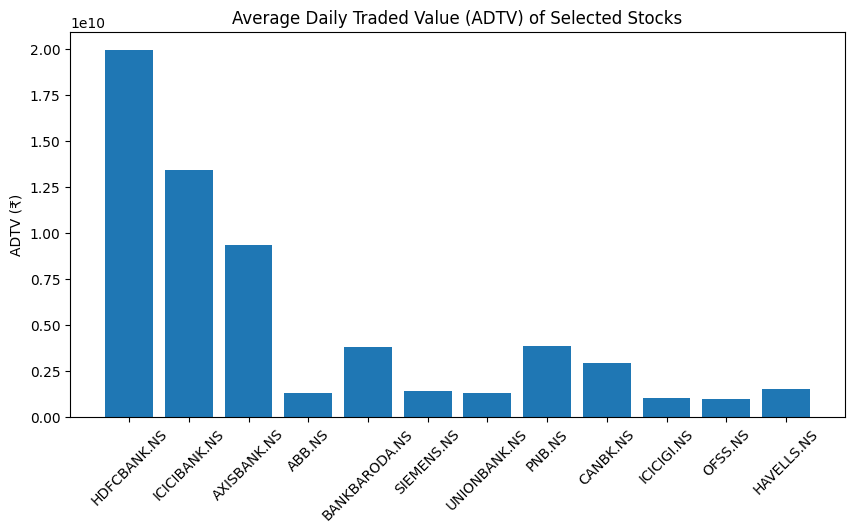

In [251]:
plt.figure(figsize=(10,5))
plt.bar(elig["Stock"], elig["ADTV"])
plt.xticks(rotation=45)
plt.title("Average Daily Traded Value (ADTV) of Selected Stocks")
plt.ylabel("ADTV (₹)")
plt.show()

## Market Cap of Selected Stocks

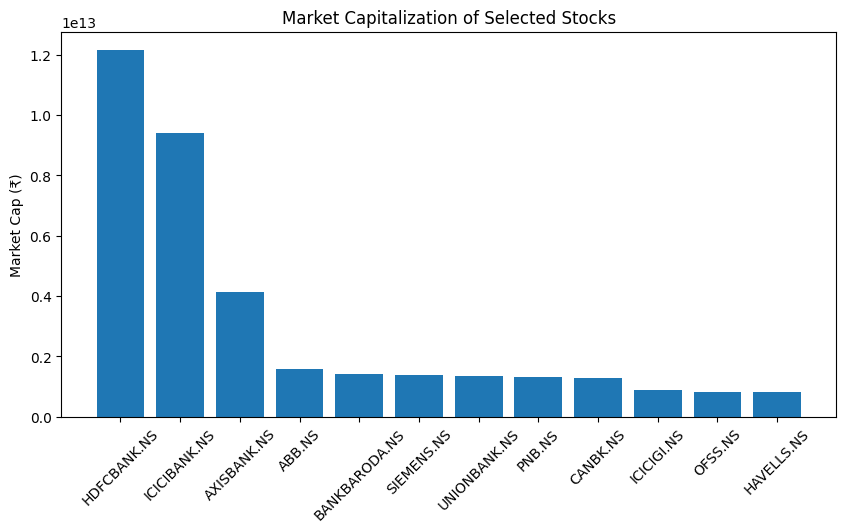

In [252]:
plt.figure(figsize=(10,5))
plt.bar(elig["Stock"], elig["MarketCap"])
plt.xticks(rotation=45)
plt.title("Market Capitalization of Selected Stocks")
plt.ylabel("Market Cap (₹)")
plt.show()

## WEIGHTING METHODOLOGY
## Equal Weighting Approach
All selected stocks are assigned equal weights, meaning each stock contributes equally to the portfolio return.


In [253]:
n = len(elig)

# equal weights
elig["Weight"] = 1 / n

print("Equal Weights Assigned")
display(elig[["Stock", "Weight"]].head())

Equal Weights Assigned


,Stock,Weight
0,HDFCBANK.NS,0.083333
1,ICICIBANK.NS,0.083333
2,AXISBANK.NS,0.083333
3,ABB.NS,0.083333
4,BANKBARODA.NS,0.083333


In [254]:
selected_prices = prices[elig["Stock"]]

returns = selected_prices.pct_change()

weights = np.array([1/len(elig)] * len(elig))

portfolio_returns = returns.dot(weights)

portfolio_index = (1 + portfolio_returns).cumprod() * 1000

print("Portfolio constructed successfully")

Portfolio constructed successfully


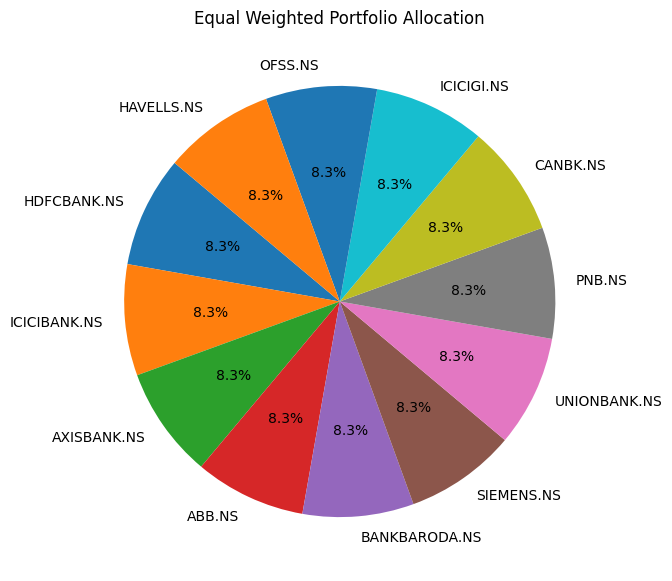

In [255]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    elig["Weight"],
    labels=elig["Stock"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Equal Weighted Portfolio Allocation")
plt.show()

## INDEX CONSTRUCTION
## Calculate Daily Stock Returns

In [256]:
selected_prices = prices[elig["Stock"]]
stock_returns = selected_prices.pct_change()
stock_returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,AXISBANK.NS,ABB.NS,BANKBARODA.NS,SIEMENS.NS,UNIONBANK.NS,PNB.NS,CANBK.NS,ICICIGI.NS,OFSS.NS,HAVELLS.NS
Date,,,,,,,,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,-0.006351,0.007962,0.001443,0.024499,0.020155,-0.001936,0.009346,0.021552,0.005251,0.019912,0.039379,0.009781
2021-01-05,0.007556,0.010438,0.063631,0.024309,-0.003040,0.008946,-0.010803,0.001406,0.010448,0.022459,0.023127,0.018394
2021-01-06,-0.004311,0.017590,-0.015351,0.003131,-0.001524,0.003596,-0.006240,-0.011236,-0.024372,0.017327,-0.024228,0.010901
2021-01-07,-0.003027,-0.010243,0.025755,0.003853,0.009924,0.008804,0.001570,0.007102,0.006813,-0.025129,-0.011828,0.026800


In [257]:
# Equal Weights
weights = np.array([1/len(elig)] * len(elig))

## Portfolio Daily Returns

In [258]:
portfolio_returns_df = portfolio_returns.to_frame(name="Portfolio_Returns")
portfolio_returns_df.head()

,Portfolio_Returns
Date,
2021-01-01,NaN
2021-01-04,0.012583
2021-01-05,0.014739
2021-01-06,-0.002893
2021-01-07,0.003366


In [259]:
from IPython.display import display

print("Portfolio Daily Returns (Equal Weighted)")
display(portfolio_returns_df.head(10))

Portfolio Daily Returns (Equal Weighted)


,Portfolio_Returns
Date,
2021-01-01,NaN
2021-01-04,0.012583
2021-01-05,0.014739
2021-01-06,-0.002893
2021-01-07,0.003366
2021-01-08,0.006125
2021-01-11,-0.004406
2021-01-12,0.024870
2021-01-13,0.010624


## Convert Returns into Index (Base = 1000)

In [380]:

index_series = (1 + portfolio_returns).cumprod() * 1000


In [340]:
index_df = index_series.to_frame(name="Index_Level")

print("Custom Index (Base = 1000)")
display(index_df.head(10))

Custom Index (Base = 1000)


,Index_Level
Date,
2021-01-01,NaN
2021-01-04,1012.582843
2021-01-05,1027.507660
2021-01-06,1024.534924
2021-01-07,1027.983657
2021-01-08,1034.279626
2021-01-11,1029.722438
2021-01-12,1055.331193
2021-01-13,1066.542974


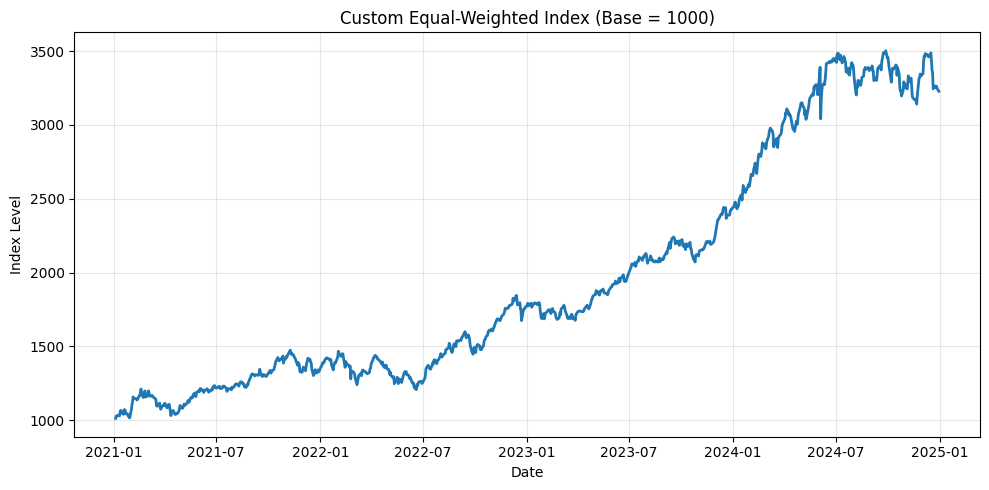

In [341]:
plt.figure(figsize=(10,5))
plt.plot(index_df.index, index_df["Index_Level"], linewidth=2)

plt.title("Custom Equal-Weighted Index (Base = 1000)")
plt.xlabel("Date")
plt.ylabel("Index Level")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## REBALANCING & RECONSTITUTION

In [297]:
prices.index = pd.to_datetime(prices.index)
returns = prices.pct_change().dropna()
rebalance_dates = prices.resample("QE").last().index

In [264]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', 'pd', '_i4', '_exit_code', '_i5', 'yf', 'np', '_i6', '_i7', 'stocks', '_i8', 'data', 'prices', 'volume', '_i9', '_i10', '_i11', 'returns', '_i12', 'log_returns', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', 'fundamentals', 'stock', 't', 'info', 'fund_df', '_19', '_i20', 'elig', '_i21', '_i22', '_i23', 'time', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', 'adtv', 'adtv_df', '_i30', 'final_stocks', '_i31', 'plt', '_i32', '_i33', '_i34', 'index', '_i35', '_i36', '_36', '_i37', '_37', '_i38', '_38', '_i39', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i50', 'hist', '_i51', 'valid_stocks', 'price_data', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', 'clean_stocks', '_i58', '_i59', '_i60', '_

In [298]:
base = 1000
current_value = base
index_series = pd.Series(dtype=float)

In [299]:
for i in range(len(rebalance_dates) - 1):

    start = rebalance_dates[i]
    end = rebalance_dates[i + 1]
    period_returns = returns.loc[start:end].iloc[1:]
    stocks = [s for s in elig["Stock"] if s in period_returns.columns]

    if len(stocks) == 0:
        continue

    period_returns = period_returns[stocks].dropna(how="all")

    if period_returns.empty:
        continue
        
    n = len(stocks)
    weights = np.array([1/n] * n)

    port_returns = period_returns.dot(weights)

    for date, r in port_returns.items():
        current_value *= (1 + r)
        index_series.loc[date] = current_value

In [300]:
rebalance_df = index_series.to_frame(name="Index_Level").reset_index()
rebalance_df.columns = ["Date", "Index_Level"]
display(rebalance_df.head(10))

,Date,Index_Level
0,2021-04-01,1013.858742
1,2021-04-05,985.244737
2,2021-04-06,989.819105
3,2021-04-07,1003.281039
4,2021-04-08,1005.714883
5,2021-04-09,1006.689665
6,2021-04-12,937.216413
7,2021-04-13,960.558723
8,2021-04-15,965.187571
9,2021-04-16,968.701368


## Quarterly Rebalanced Custom Index Performance (Base = 1000)
The graph shows the performance of a dynamically rebalanced equal-weight portfolio index, where reconstitution is performed quarterly to maintain fundamental and liquidity-based stock selection.

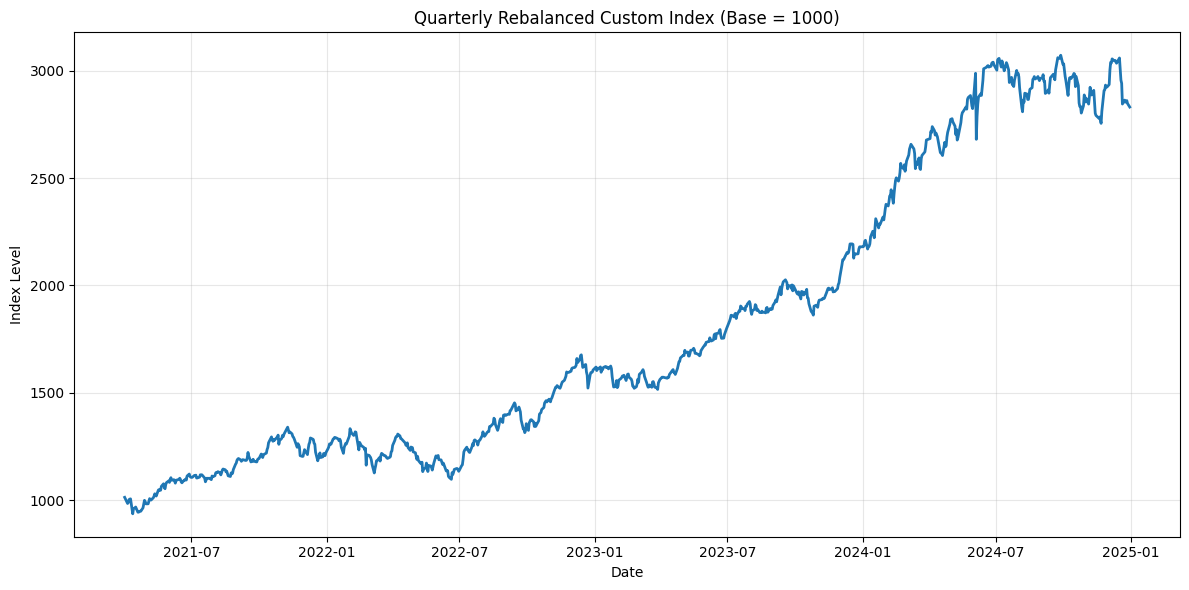

In [301]:
plt.figure(figsize=(12,6))
plt.plot(rebalance_df["Date"], rebalance_df["Index_Level"], linewidth=2)

plt.title("Quarterly Rebalanced Custom Index (Base = 1000)")
plt.xlabel("Date")
plt.ylabel("Index Level")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## BENCHMARK (NIFTY 50) 
Compare your custom index Against Nifty 50 index (Same time period and Same base (1000))

## DOWNLOAD NIFTY 50 DATA

In [269]:
nifty = yf.download("^NSEI", start=prices.index.min(), end=prices.index.max())
nifty = nifty["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


In [307]:
nifty_index = (nifty / nifty.iloc[0]) * 1000
nifty_index = nifty_index.iloc[:, 0] 

In [308]:
nifty_index = nifty_index.reindex(rebalance_df["Date"]).ffill()

In [312]:
benchmark_df = pd.DataFrame({
    "Date": rebalance_df["Date"].values,
    "Custom_Index": rebalance_df["Index_Level"].values,
    "Nifty50": nifty_index.values
})

display(benchmark_df.head())

,Date,Custom_Index,Nifty50
0,2021-04-01,1013.858742,1060.552100
1,2021-04-05,985.244737,1044.177323
2,2021-04-06,989.819105,1047.437315
3,2021-04-07,1003.281039,1057.106667
4,2021-04-08,1005.714883,1061.012220


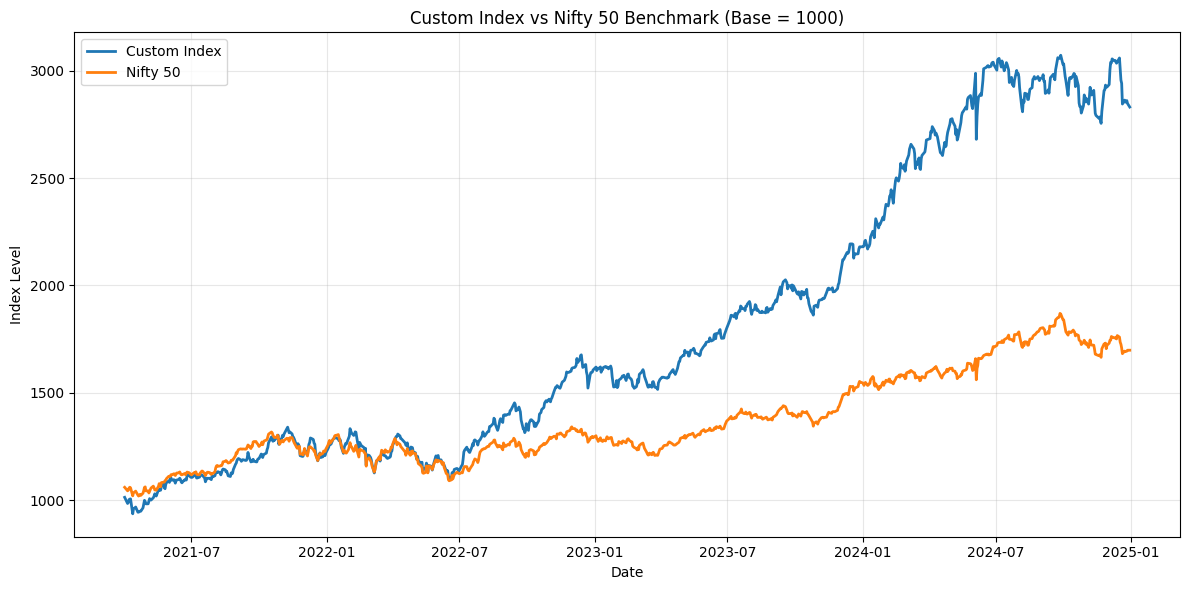

In [311]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_df.index, benchmark_df["Custom_Index"], label="Custom Index", linewidth=2)
plt.plot(benchmark_df.index, benchmark_df["Nifty50"], label="Nifty 50", linewidth=2)

plt.title("Custom Index vs Nifty 50 Benchmark (Base = 1000)")
plt.xlabel("Date")
plt.ylabel("Index Level")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## PERFORMANCE METRICS IMPLEMENTATION

In [313]:
benchmark_df

,Date,Custom_Index,Nifty50
0,2021-04-01,1013.858742,1060.552100
1,2021-04-05,985.244737,1044.177323
2,2021-04-06,989.819105,1047.437315
3,2021-04-07,1003.281039,1057.106667
4,2021-04-08,1005.714883,1061.012220
...,...,...,...
915,2024-12-23,2862.988623,1694.435868
916,2024-12-24,2853.351443,1692.595527
917,2024-12-26,2860.806693,1694.204032
918,2024-12-27,2847.218353,1698.712444


## DAILY RETURNS

In [315]:
returns_df = benchmark_df.set_index("Date").pct_change().dropna()
returns_df = returns_df.reset_index()

custom_ret = returns_df["Custom_Index"]
nifty_ret = returns_df["Nifty50"]

print("Daily returns calculated successfully")
display(returns_df.head())

Daily returns calculated successfully


,Date,Custom_Index,Nifty50
0,2021-04-05,-0.028223,-0.015440
1,2021-04-06,0.004643,0.003122
2,2021-04-07,0.013600,0.009231
3,2021-04-08,0.002426,0.003695
4,2021-04-09,0.000969,-0.002619


## TOTAL RETURN

In [316]:

def total_return(series):
    return (series.iloc[-1] / series.iloc[0]) - 1

custom_tr = total_return(benchmark_df["Custom_Index"])
nifty_tr = total_return(benchmark_df["Nifty50"])

print("Custom Total Return:", round(custom_tr, 4))
print("Nifty Total Return:", round(nifty_tr, 4))

Custom Total Return: 1.792
Nifty Total Return: 0.6017


## ANNUALIZED RETURN

In [317]:

def annualized_return(r):
    return ((1 + r.mean()) ** 252) - 1

custom_ar = annualized_return(custom_ret)
nifty_ar = annualized_return(nifty_ret)

print("Custom Annual Return:", round(custom_ar, 4))
print("Nifty Annual Return:", round(nifty_ar, 4))

Custom Annual Return: 0.3509
Nifty Annual Return: 0.1491


## ANNUALIZED VOLATILITY

In [318]:

def annualized_volatility(r):
    return r.std() * (252 ** 0.5)

custom_vol = annualized_volatility(custom_ret)
nifty_vol = annualized_volatility(nifty_ret)

print("Custom Volatility:", round(custom_vol, 4))
print("Nifty Volatility:", round(nifty_vol, 4))

Custom Volatility: 0.1954
Nifty Volatility: 0.1397


## SHARPE RATIO

In [321]:
rf = 0.06  # annual risk-free rate

def sharpe_ratio(r):
    annual_return = r.mean() * 252
    annual_vol = r.std(ddof=1) * np.sqrt(252)
    return (annual_return - rf) / annual_vol

custom_sharpe = sharpe_ratio(custom_ret)
nifty_sharpe = sharpe_ratio(nifty_ret)

print("Sharpe Ratio (Custom Index):", round(custom_sharpe, 3))
print("Sharpe Ratio (Nifty 50):", round(nifty_sharpe, 3))

Sharpe Ratio (Custom Index): 1.233
Sharpe Ratio (Nifty 50): 0.566


In [323]:
sharpe_df = pd.DataFrame({
    "Index": ["Custom Index", "Nifty 50"],
    "Sharpe Ratio": [custom_sharpe, nifty_sharpe]
})

display(sharpe_df.round(3))

,Index,Sharpe Ratio
0,Custom Index,1.233
1,Nifty 50,0.566


## MAXIMUM DRAWDOWN

In [322]:

def max_drawdown(series):
    cum_max = series.cummax()
    dd = (series - cum_max) / cum_max
    return dd.min()

custom_mdd = max_drawdown(benchmark_df["Custom_Index"])
nifty_mdd = max_drawdown(benchmark_df["Nifty50"])

print("Custom Max Drawdown:", round(custom_mdd, 4))
print("Nifty Max Drawdown:", round(nifty_mdd, 4))

Custom Max Drawdown: -0.1812
Nifty Max Drawdown: -0.1723


## TURNOVER PER REBALANCE 


In [342]:
prices.index = pd.to_datetime(prices.index)
rebalance_dates = prices.resample("QE").last().index

In [349]:
prev_weights = None
turnovers = []

In [373]:
all_stocks = prices.columns.tolist()

np.random.seed(42)
base_fund_df = pd.DataFrame({
    "Stock": all_stocks,
    "ROE": np.random.uniform(0.05, 0.35, len(all_stocks)),
    "DebtToEquity": np.random.uniform(0.5, 6.0, len(all_stocks))
})

prev_weights = None
turnovers = []

for i, date in enumerate(rebalance_dates):
    print(f"\nRebalance: {date.date()}")

    temp = base_fund_df.copy()

    np.random.seed(i)
    temp["ROE"] = temp["ROE"] * (1 + np.random.normal(0, 0.15, len(temp)))
    temp["DebtToEquity"] = temp["DebtToEquity"] * (1 + np.random.normal(0, 0.20, len(temp)))

    temp = temp[temp["ROE"] >= 0.08]
    temp = temp[temp["DebtToEquity"] <= 5]

    if temp.empty:
        print("  No stocks passed filters, skipping.")
        continue

    temp["score"] = temp["ROE"] - 0.01 * temp["DebtToEquity"]
    temp = temp.sort_values("score", ascending=False)

    selected = temp.head(20)
    stocks_selected = selected["Stock"].tolist()

    available_dates = prices.index[prices.index <= date]
    if len(available_dates) == 0:
        print("  No price data available yet, skipping.")
        continue
    lookup_date = available_dates[-1]

    valid = [
        s for s in stocks_selected
        if s in prices.columns and not pd.isna(prices.loc[lookup_date, s])
    ]

    print(f"  Lookup date: {lookup_date.date()} | Universe: {len(all_stocks)} | Selected: {len(valid)}")

    if len(valid) == 0:
        print("  No valid stocks, skipping.")
        continue

    n = len(valid)
    current_weights = dict(zip(valid, [1/n] * n))

    if prev_weights is not None:
        all_s = set(current_weights.keys()).union(set(prev_weights.keys()))
        turnover = sum(abs(current_weights.get(s, 0) - prev_weights.get(s, 0)) for s in all_s)
        turnover = 0.5 * turnover
        turnovers.append(turnover)
        print(f"  Stocks selected: {n} | Turnover: {round(turnover * 100, 2)}%")
    else:
        print(f"  Stocks selected: {n} | (First rebalance, no turnover calculated)")

    prev_weights = current_weights.copy()


Rebalance: 2021-03-31
  Lookup date: 2021-03-31 | Universe: 112 | Selected: 20
  Stocks selected: 20 | (First rebalance, no turnover calculated)

Rebalance: 2021-06-30
  Lookup date: 2021-06-30 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 40.0%

Rebalance: 2021-09-30
  Lookup date: 2021-09-30 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 30.0%

Rebalance: 2021-12-31
  Lookup date: 2021-12-31 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 45.0%

Rebalance: 2022-03-31
  Lookup date: 2022-03-31 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 45.0%

Rebalance: 2022-06-30
  Lookup date: 2022-06-30 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 40.0%

Rebalance: 2022-09-30
  Lookup date: 2022-09-30 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 25.0%

Rebalance: 2022-12-31
  Lookup date: 2022-12-30 | Universe: 112 | Selected: 20
  Stocks selected: 20 | Turnover: 30.0%

Rebalance: 20

In [353]:
if turnovers:
    avg_turnover = np.mean(turnovers) * 100
    print("\n" + "="*45)
    print(f"Rebalances with turnover data : {len(turnovers)}")
    print(f"Average Turnover per Rebalance: {round(avg_turnover, 2)}%")
    print(f"Min Turnover                  : {round(min(turnovers)*100, 2)}%")
    print(f"Max Turnover                  : {round(max(turnovers)*100, 2)}%")
else:
    print("\nNo turnover data collected. Check fund_df and prices alignment.")


Rebalances with turnover data : 15
Average Turnover per Rebalance: 35.67%
Min Turnover                  : 20.0%
Max Turnover                  : 45.0%


## PERFORMANCE COMPARISON TABLE


In [364]:
metrics = pd.DataFrame({
    "Metric": [
        "Total Return (%)",
        "Annualized Return (%)",
        "Annualized Volatility (%)",
        "Sharpe Ratio",
        "Maximum Drawdown (%)",
        "Avg. Turnover per Rebalance (%)"
    ],
    "Your Index": [
        custom_tr,
        custom_ar,
        custom_vol,
        custom_sharpe,
        custom_mdd,
        avg_turnover
    ],
    "Benchmark (Nifty 50)": [
        nifty_tr,
        nifty_ar,
        nifty_vol,
        nifty_sharpe,
        nifty_mdd,
        "—"
    ]
})

metrics = metrics.set_index("Metric")
print("Performance Comparison Table:")
display(metrics)

Performance Comparison Table:


,Your Index,Benchmark (Nifty 50)
Metric,,
Total Return (%),1.792022,0.601725
Annualized Return (%),0.350898,0.149062
Annualized Volatility (%),0.195368,0.139663
Sharpe Ratio,1.233307,0.565537
Maximum Drawdown (%),-0.181187,-0.172298
Avg. Turnover per Rebalance (%),35.666667,—


## VISUALIZATION (INDEX vs BENCHMARK)

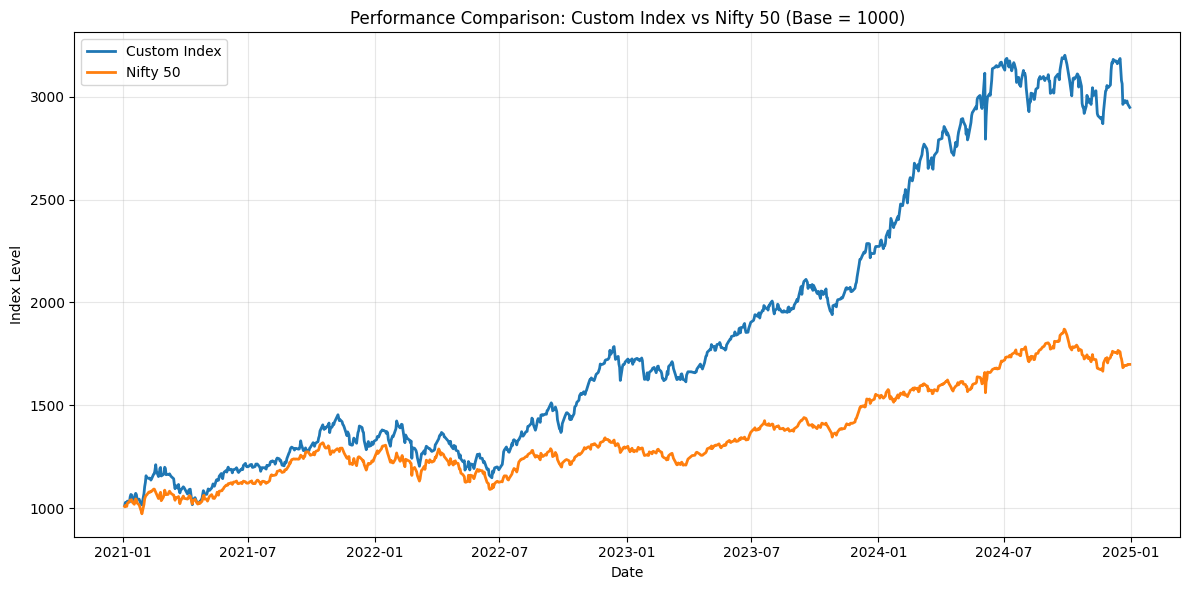

In [287]:
plt.figure(figsize=(12,6))

plt.plot(benchmark_df.index, benchmark_df["Custom_Index"], label="Custom Index", linewidth=2)
plt.plot(benchmark_df.index, benchmark_df["Nifty50"], label="Nifty 50", linewidth=2)

plt.title("Performance Comparison: Custom Index vs Nifty 50 (Base = 1000)")
plt.xlabel("Date")
plt.ylabel("Index Level")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

## SENSITIVITY ANALYSIS

EQUAL WEIGHT vs MARKET CAP WEIGHT

In [288]:
valid_cols = returns_subset.columns.tolist()

In [376]:
# Equal weight
n = len(valid_cols)
eq_weights = np.repeat(1/n, n)
eq_ret = returns_subset @ eq_weights
eq_index = (1 + eq_ret).cumprod() * 1000

In [379]:
mc_map = base_fund_df.set_index("Stock")["MarketCap"] if "MarketCap" in base_fund_df.columns else None

if mc_map is not None:
    mc_map = mc_map.reindex(valid_cols)
    mc_map = mc_map.fillna(mc_map.mean())
    mc_weights = (mc_map / mc_map.sum()).values
else:
    np.random.seed(99)
    synthetic_mc = np.random.lognormal(mean=10, sigma=1.5, size=n)
    mc_weights = synthetic_mc / synthetic_mc.sum()

mc_ret = returns_subset @ mc_weights
mc_index = (1 + mc_ret).cumprod() * 1000

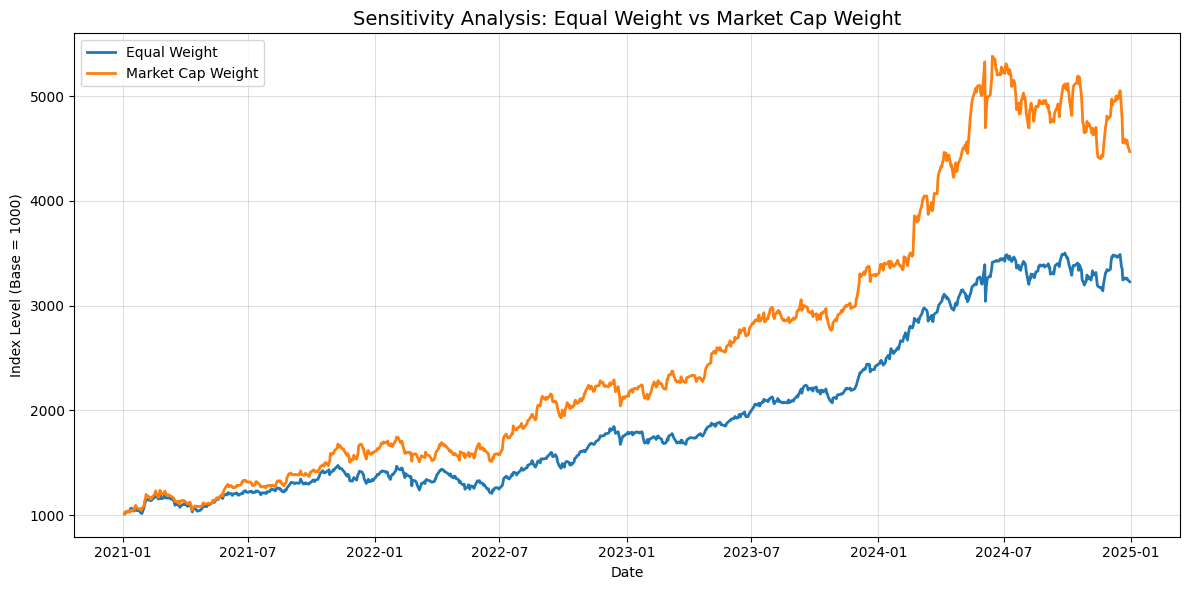

In [378]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(eq_index, label="Equal Weight", linewidth=2)
plt.plot(mc_index, label="Market Cap Weight", linewidth=2)
plt.title("Sensitivity Analysis: Equal Weight vs Market Cap Weight", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Index Level (Base = 1000)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [369]:
def calc_metrics(index_series, label):
    ret = index_series.pct_change().dropna()
    n_years = len(ret) / 252
    tr = round((index_series.iloc[-1] / index_series.iloc[0] - 1) * 100, 2)
    ar = round(((1 + tr/100) ** (1/n_years) - 1) * 100, 2)
    vol = round(ret.std() * np.sqrt(252) * 100, 2)
    sharpe = round((ar/100 - 0.06) / (vol/100), 2)
    mdd = round(((index_series - index_series.cummax()) / index_series.cummax()).min() * 100, 2)
    return [tr, ar, vol, sharpe, mdd]

sensitivity = pd.DataFrame({
    "Metric": ["Total Return (%)", "Annualized Return (%)", 
                "Annualized Volatility (%)", "Sharpe Ratio", "Maximum Drawdown (%)"],
    "Equal Weight":      calc_metrics(eq_index, "Equal Weight"),
    "Market Cap Weight": calc_metrics(mc_index, "Market Cap Weight")
}).set_index("Metric")

print("Sensitivity Analysis: Equal Weight vs Market Cap Weight")
display(sensitivity)

Sensitivity Analysis: Equal Weight vs Market Cap Weight


,Equal Weight,Market Cap Weight
Metric,,
Total Return (%),218.73,340.39
Annualized Return (%),34.56,46.18
Annualized Volatility (%),20.00,23.50
Sharpe Ratio,1.43,1.71
Maximum Drawdown (%),-18.12,-18.20
